# Chapter 5: Getting Started with pandas

## 5.3 Summarizing and Computing Descriptive Statics
> 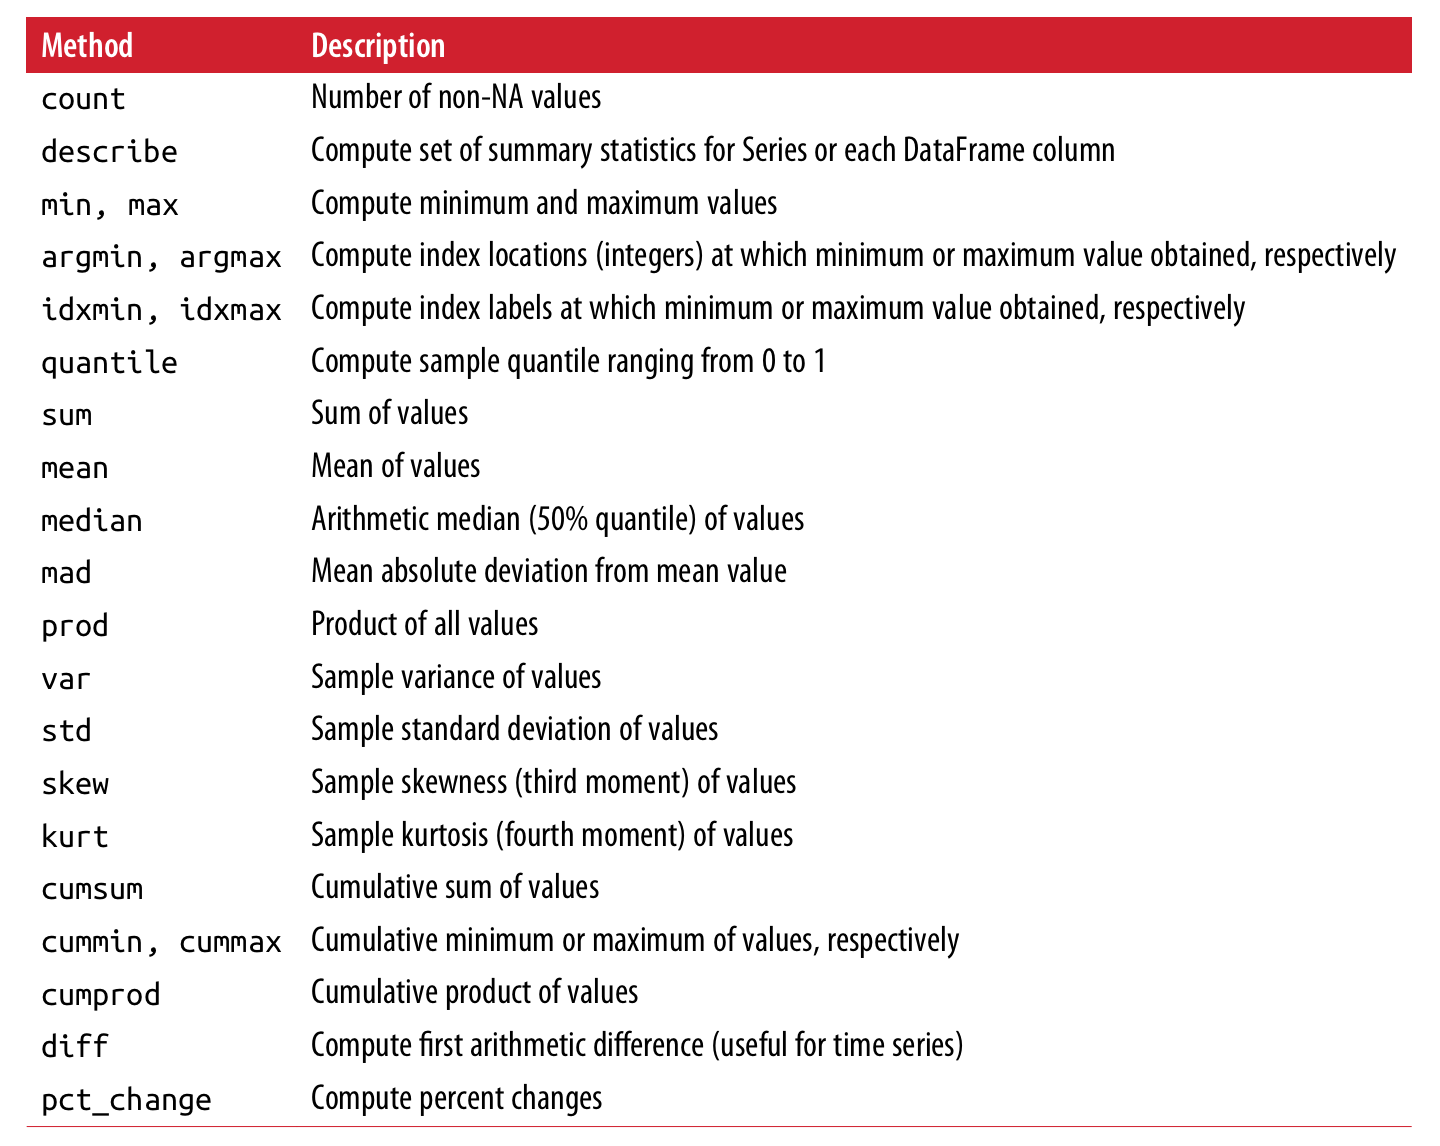
> 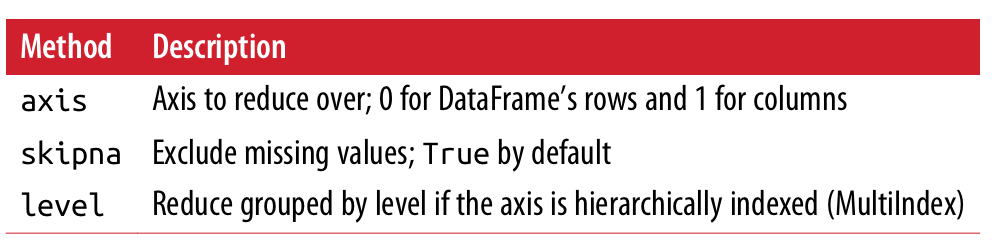

In [3]:
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                 [np.nan, np.nan], [0.75, -1.3]],
                 index=['a','b','c','d'],
                 columns=['one', 'two'])
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [4]:
df.mean(axis='columns') # or axis = 1

a    1.400
b    1.300
c      NaN
d   -0.275
dtype: float64

In [6]:
df.mean(axis='columns', skipna=False)

a      NaN
b    1.300
c      NaN
d   -0.275
dtype: float64

In [10]:
df.idxmax()
df.cumsum()
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [13]:
obj = pd.Series(['a','a','b','c']*4)
obj.describe()

count     16
unique     3
top        a
freq       8
dtype: object

- On non-numeric data, *descibe* produces alternative summary statistics:

### Correlation and Covariance

In [3]:
import pandas_datareader.data as web
all_data = {ticker: web.get_data_yahoo(ticker)
           for ticker in ['AAPL','IBM','MSFT','GOOG']}

In [6]:
price = pd.DataFrame({ticker: data['Adj Close']
                     for ticker, data in all_data.items()})
volume = pd.DataFrame({ticker: data['Volume']
                      for ticker, data in all_data.items()})

In [7]:
returns = price.pct_change()
returns.tail()

,AAPL,IBM,MSFT,GOOG
Date,,,,
2022-08-29,-0.013690,-0.000537,-0.010668,-0.008625
2022-08-30,-0.015305,-0.005602,-0.008521,-0.003897
2022-08-31,-0.010635,-0.008721,-0.005704,-0.006915
2022-09-01,0.004707,0.009420,-0.004092,0.012826
2022-09-02,-0.013611,-0.014422,-0.016667,-0.016915


In [12]:
returns.corr() # returns.cov()

,AAPL,IBM,MSFT,GOOG
AAPL,1.000000,0.438293,0.761423,0.686660
IBM,0.438293,1.000000,0.478682,0.446418
MSFT,0.761423,0.478682,1.000000,0.788008
GOOG,0.686660,0.446418,0.788008,1.000000


In [13]:
returns['MSFT'].corr(returns['IBM']) # = returns.MSFT.corr(returns.IBM)

0.4786815338768153

In [15]:
returns.corrwith(returns.IBM)

AAPL    0.438293
IBM     1.000000
MSFT    0.478682
GOOG    0.446418
dtype: float64

### Unique Values, Value Counts, and Membership
- Another class of related methods extracts information about the values contained in a **one-dimenstional Series**.

>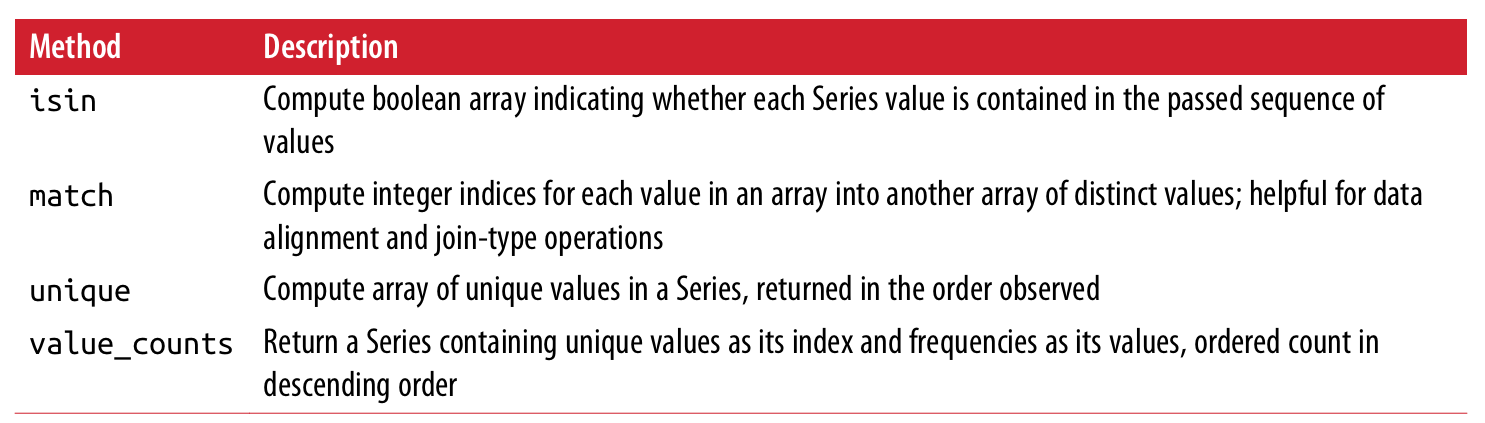

In [4]:
obj = pd.Series(['c','a','d','a','a','b','b','c','c'])
uniques = obj.unique()
uniques

array(['c', 'a', 'd', 'b'], dtype=object)

- ***unique***, which gives you an array of the unique values in **Series**
- The unique values are not necessarily returned in sorted order, but could be sorted after the fact if needed (***uniques.sorted()***

In [5]:
obj.value_counts() # = pd.value_counts(obj.values)

c    3
a    3
b    2
d    1
dtype: int64

- ***value_counts***, which computes a Series containing value frequencies:
- The Series is sorted by value in descending order as a convenience.

In [7]:
mask = obj.isin(['b', 'c'])
mask

0     True
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
dtype: bool

In [8]:
obj[mask]

0    c
5    b
6    b
7    c
8    c
dtype: object

- ***isin*** performs a vectorized set membership check and can be useful in filtering a dataset down to a subset of values in a Series or column in a DataFrame

- the ***Index.get_indexer*** method, which gives you an index array from an array of possibly non-distinct values into another array of distinct values:

In [9]:
to_match = pd.Series(['c','a','b','b','c','a'])
unique_vals = pd.Series(['c','b','a'])
pd.Index(unique_vals).get_indexer(to_match)

array([0, 2, 1, 1, 0, 2])

In [10]:
data = pd.DataFrame({'Qu1':[1,3,4,3,4],
                    'Qu2':[2,3,1,2,3],
                    'Qu3':[1,5,2,4,4,]})
data

,Qu1,Qu2,Qu3
0,1,2,1
1,3,3,5
2,4,1,2
3,3,2,4
4,4,3,4


In [13]:
# Passing "pandas.value_counts" to this DataFrame's "apply" function gives:
result = data.apply(pd.value_counts).fillna(0)
result

,Qu1,Qu2,Qu3
1,1.0,1.0,1.0
2,0.0,2.0,1.0
3,2.0,2.0,0.0
4,2.0,0.0,2.0
5,0.0,0.0,1.0


- Here, the **row labels** in the result are the distict values occuring in all of the columns.
- The **values** are the respective counts of these values in each column.
- 5는 첫번째 열에서 0개 나옴(5행 1열), 1은 2열에서 1번 나옴(1행 2열)